<a href="https://colab.research.google.com/github/toshi039a/retail-demand-forecast/blob/main/%E9%9B%A2%E8%84%B1%E4%BA%88%E6%B8%ACPF_20260429.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC顧客データを用いた離脱予測モデル構築

## 1. 概要とデータ読み込み

本分析では、Kaggleの「Ecommerce Customer Churn Analysis and Prediction」データセットを使用する。

本データは、ECサービスにおける顧客属性・利用状況・購買行動に関するデータであり、顧客が離脱するかどうかを予測することを目的とする。

顧客離脱予測は、既存顧客の維持・売上の機会損失防止・マーケティング施策の最適化において重要な分析テーマである。  
離脱リスクの高い顧客を事前に把握できれば、クーポン配布、サポート強化、利用促進施策などの打ち手につなげることができる。

なお、本データセットでは `Churn` は顧客離脱フラグとして提供されているが、離脱の具体的な定義は明記されていない。  
そのため、本分析では `Churn=1` を「ECサービスから離脱したと判定された顧客」、`Churn=0` を「継続顧客」として扱う。

本Notebookでは、以下の流れで離脱予測モデルを構築する。

1. 概要とデータ読み込み
2. 探索的データ分析（EDA）
3. 前処理と特徴量整理
4. モデリング・評価・モデル解釈
5. 閾値調整と施策提案
6. まとめ

### 1.1 データ構造の確認

まずは、データの行数・列数・カラムの型、欠損値の有無を確認する。

本データは顧客単位のデータであり、1行が1顧客を表す。  
目的変数は `Churn` であり、その他のカラムには顧客属性・利用状況・購買行動に関する情報が含まれている。

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 本分析ではKaggleの「Ecommerce Customer Churn Analysis and Prediction」を使用した。
# ECサービスの顧客属性・利用状況・購買行動に関するデータであり、
# 顧客が離脱するかどうかを予測する二値分類問題として扱う。
# データは以下から取得可能である。
# https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/離脱予測PF/E Commerce Dataset.xlsx'

df = pd.read_excel(file_path, sheet_name='E Comm')
data_dict = pd.read_excel(file_path, sheet_name='Data Dict')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

データは5,630行・20列で構成されている。  
数値変数とカテゴリ変数が混在しており、一部の数値変数には欠損値が存在する。

特に、以下のようなカラムに欠損値が確認される。

- `Tenure`
- `WarehouseToHome`
- `HourSpendOnApp`
- `OrderAmountHikeFromlastYear`
- `CouponUsed`
- `OrderCount`
- `DaySinceLastOrder`

これらの欠損値については、後続の前処理で適切に処理する。

### 1.2 カラム定義の確認

`Data Dict` シートには、各カラムの説明が記載されている。  
EDAやモデル解釈を行う前に、各変数の意味を確認する。

In [20]:
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


本分析で特に重要と思われる主なカラムは以下の通りである。

- `Churn`：顧客離脱フラグ
- `Tenure`：顧客の利用期間
- `SatisfactionScore`：満足度スコア
- `Complain`：クレーム有無
- `OrderCount`：直近月の注文回数
- `DaySinceLastOrder`：最終注文からの日数
- `CashbackAmount`：キャッシュバック金額

なお、`CustomerID` は顧客識別用のIDであり、予測に直接使用しない。

### 1.3 目的変数の確認

本分析の目的変数である `Churn` の分布を確認する。

離脱予測では、離脱顧客が継続顧客より少ないケースが多いため、まずはクラス比率を確認する。  
クラス不均衡がある場合、Accuracyだけでは少数派である離脱顧客の検出性能を適切に評価できない。

そのため、後続のモデル評価では、Precision、Recall、F1-score、ROC-AUC、PR-AUCを確認する。  
特に本分析では、離脱顧客の見逃しを抑えるためRecallを重視しつつ、施策対象が過剰にならないようPrecisionとのバランスも確認する。

In [21]:
# 目的変数の件数確認
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [22]:
# 離脱率の確認
churn_rate = df['Churn'].mean()

print(f'離脱率: {churn_rate:.2%}')

離脱率: 16.84%


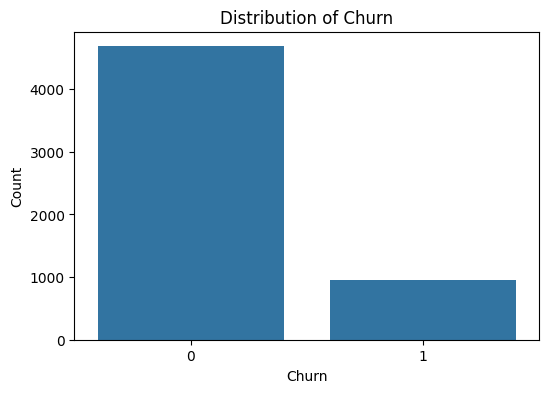

In [23]:
# Churnの分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- `Churn` の分布を確認したところ、離脱率は16.84%であり、継続顧客が多数を占めている。

- このことから、本データはクラス不均衡を含む二値分類問題であると考えられる。  
- そのため、後続のモデル評価ではAccuracyだけでなく、RecallやPrecision、PR-AUCなども重視する。

### 1.4 欠損値の詳細確認

`df.info()` により、一部の数値変数に欠損値が存在することが確認された。

ここでは、各カラムの欠損数と欠損率を確認し、後続の前処理方針を検討する。

In [24]:
# 欠損数と欠損率を確認
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean()
}).sort_values('missing_count', ascending=False)

# 欠損値があるカラムのみ表示
missing_df = missing_df[missing_df['missing_count'] > 0].copy()
missing_df

,missing_count,missing_rate
DaySinceLastOrder,307,0.054529
OrderAmountHikeFromlastYear,265,0.047069
Tenure,264,0.046892
OrderCount,258,0.045826
CouponUsed,256,0.045471
HourSpendOnApp,255,0.045293
WarehouseToHome,251,0.044583


- 欠損値を確認したところ、7つの数値変数に欠損が存在していることが分かった。
- 最も欠損が多い `DaySinceLastOrder` でも欠損率は5.45%であり、全体として欠損率は高くない。
- 欠損率が極端に高いカラムはないため、カラム削除ではなく補完によって対応する方針とする。
- 後続の前処理では、数値変数の欠損値を中央値で補完する。

### 1.5 数値変数・カテゴリ変数の整理

モデル構築に向けて、数値変数とカテゴリ変数を整理する。

本データには、利用期間・注文回数・満足度・クレーム有無などの数値変数と、ログイン端末・支払い方法・性別・注文カテゴリ・婚姻状況などのカテゴリ変数が含まれている。

後続の前処理では、数値変数には欠損値補完を行い、カテゴリ変数にはエンコーディングを行う。

In [25]:
# 数値変数の抽出
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [26]:
# カテゴリ変数の抽出
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cat_cols

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [27]:
# カテゴリ変数のユニーク数確認
df[cat_cols].nunique()

,0
PreferredLoginDevice,3
PreferredPaymentMode,7
Gender,2
PreferedOrderCat,6
MaritalStatus,3


In [28]:
# 各カテゴリ変数の値を確認
for col in cat_cols:
    print(f'【{col}】')
    print(df[col].value_counts(dropna=False))
    print('-' * 50)

【PreferredLoginDevice】
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
--------------------------------------------------
【PreferredPaymentMode】
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
--------------------------------------------------
【Gender】
Gender
Male      3384
Female    2246
Name: count, dtype: int64
--------------------------------------------------
【PreferedOrderCat】
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
--------------------------------------------------
【MaritalStatus】
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
---------------

- 本データには、数値変数とカテゴリ変数の両方のタイプの特徴量が含まれている。
- カテゴリ変数には、ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況が含まれている。
- カテゴリ変数はいずれもユニーク数が多すぎず、後続の前処理ではOne-Hot Encodingで扱いやすい構成である。
- `PreferredLoginDevice` では `Mobile Phone` と `Phone`、`PreferredPaymentMode` では `Credit Card` と `CC`、`COD` と `Cash on Delivery` のように、意味が近いと思われるカテゴリが存在している。
- ただし、本データセット上でこれらが完全に同一カテゴリであるとは明記されていないため、本分析では元データのカテゴリを大きく加工せず、前処理でエンコーディングを行う方針とする。（実務では、これらが同一カテゴリかどうかをデータ定義や業務担当者への確認によって判断し、必要に応じて表記ゆれの統一を行う）
- `CustomerID` は顧客識別用のIDであり、予測に直接使用しない。
- `Churn` は目的変数であるため、説明変数からは除外する。

## 2. 探索的データ分析（EDA）

ここでは、目的変数である `Churn` と各説明変数の関係を確認する。

特に、以下の観点から離脱傾向を把握する。

1. 利用期間と離脱率の関係
2. 満足度スコアと離脱率の関係
3. クレーム有無と離脱率の関係
4. 注文回数と離脱率の関係
5. 最終注文からの日数と離脱率の関係
6. カテゴリ変数ごとの離脱率
7. 数値変数同士の相関

EDAを通じて、どのような顧客が離脱しやすい傾向にあるかを把握し、後続のモデル構築や施策提案につなげる。

### 2.1 利用期間と離脱率の関係

顧客の利用期間を表す `Tenure` と離脱率の関係を確認する。

一般的に、利用期間が短い顧客はサービスへの定着度が低く、離脱しやすい可能性がある。  
一方で、利用期間が長い顧客は継続利用の傾向が強いと考えられる。

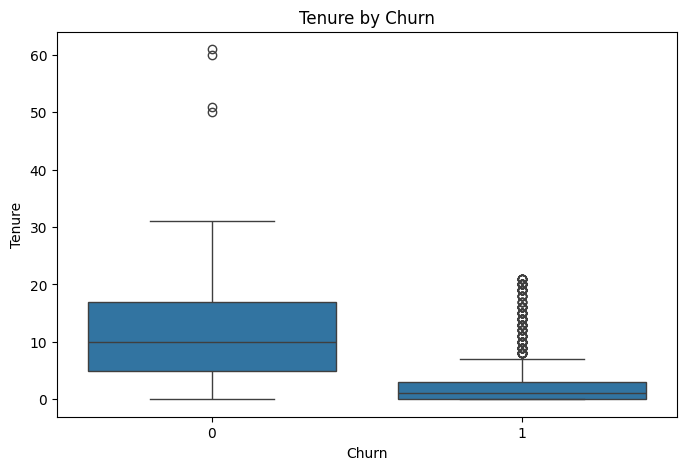

In [29]:
# Churn別にTenureの分布を確認
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

In [30]:
# Tenureを各区間に分ける
df['Tenure_bin'] = pd.cut(
    df['Tenure'],
    bins=[0, 3, 6, 12, 24, np.inf],
    labels=['0-3', '4-6', '7-12', '13-24', '25+'],
    include_lowest=True
)

# Tenure区間ごとの離脱率と件数を集計
tenure_churn = df.groupby('Tenure_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

tenure_churn

,Tenure_bin,churn_rate,count
0,0-3,0.418590,1560
1,4-6,0.074576,590
2,7-12,0.056818,1320
3,13-24,0.064758,1467
4,25+,0.000000,429


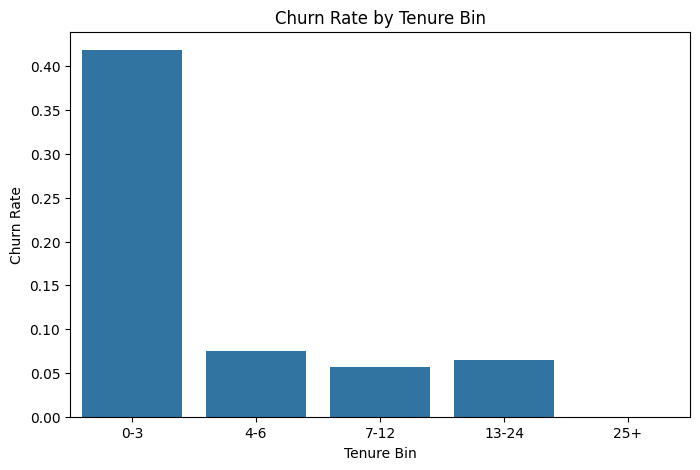

In [31]:
# 各Tenure区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x='Tenure_bin', y='churn_rate')
plt.title('Churn Rate by Tenure Bin')
plt.xlabel('Tenure Bin')
plt.ylabel('Churn Rate')
plt.show()

- `Tenure` を区間ごとに分けて離脱率を確認した。
- 利用期間が `0-3` の顧客では離脱率が約41.9%と高く、利用開始初期の顧客ほど離脱しやすい傾向が見られる。
- 一方で、`4-6` 以降の区間では離脱率が大きく低下しており、一定期間利用を継続した顧客は離脱しにくくなる傾向がある。
- `25+` の区間では、このデータ上では離脱率が0%となっている。（ただし、区間ごとの件数にも差があるため、離脱率だけでなく件数も確認しながら解釈する必要がある）
- この結果から、`Tenure` は離脱予測において重要な特徴量となる可能性がある。
- 実務においては、利用開始初期の顧客に対するオンボーディング施策や利用促進施策が離脱防止に有効である可能性がある。

### 2.2 満足度スコアと離脱率の関係

サービス評価に関するスコアである `SatisfactionScore` と離脱率の関係を確認する。

本データセットでは `SatisfactionScore` のスコアの向きが明記されていないため、値が高いほど満足度が高い、または低いとは断定せず、スコアごとの離脱率の違いを確認する。

In [32]:
# SatisfactionScoreごとの離脱率と件数を集計
satisfaction_churn = df.groupby('SatisfactionScore').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

satisfaction_churn

,SatisfactionScore,churn_rate,count
0,1,0.115120,1164
1,2,0.126280,586
2,3,0.171967,1698
3,4,0.171322,1074
4,5,0.238267,1108


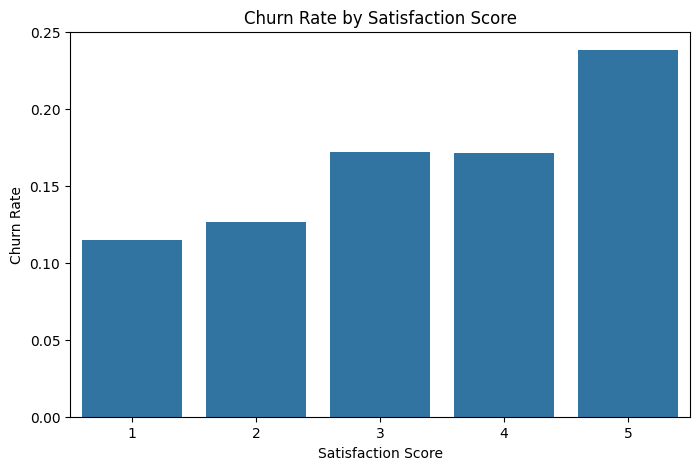

In [33]:
# SatisfactionScoreごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=satisfaction_churn, x='SatisfactionScore', y='churn_rate')
plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Churn Rate')
plt.show()

- `SatisfactionScore` ごとの離脱率を確認したところ、スコアによって離脱率に差が見られた。
- 本データセットでは `SatisfactionScore` のスコアの向きが明記されていないため、値が高いほど満足度が高い、または低いとは断定しない。
- 一方で、`SatisfactionScore=5` の顧客では離脱率が高くなっており、離脱予測において有用な特徴量となる可能性がある。
- 後続のモデル構築では、`SatisfactionScore` を特徴量として使用し、モデル内での重要度を確認する。

### 2.3 クレーム有無と離脱率の関係

クレーム有無を表す `Complain` と離脱率の関係を確認する。

クレームがある顧客は、サービス体験に不満を持っている可能性があり、離脱リスクが高いと考えられる。

In [34]:
# Complainごとの離脱率と件数を集計
complain_churn = df.groupby('Complain').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

complain_churn

,Complain,churn_rate,count
0,0,0.109290,4026
1,1,0.316708,1604


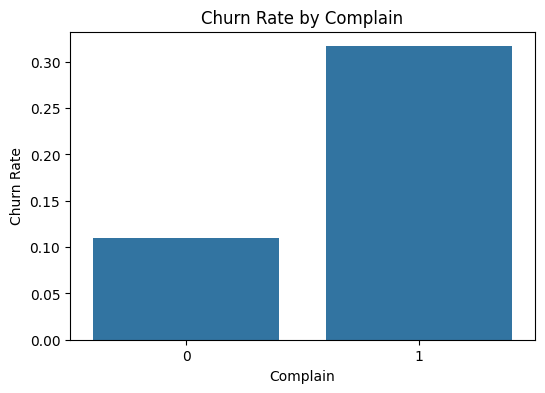

In [35]:
# Complainごとの離脱率を可視化
plt.figure(figsize=(6, 4))
sns.barplot(data=complain_churn, x='Complain', y='churn_rate')
plt.title('Churn Rate by Complain')
plt.xlabel('Complain')
plt.ylabel('Churn Rate')
plt.show()

- `Complain` ごとの離脱率を確認したところ、クレームありの顧客はクレームなしの顧客よりも離脱率が高い傾向が見られた。
- クレームなしの顧客の離脱率は約10.9%、クレームありの顧客の離脱率は約31.7%であった。
- このことから、クレーム有無は離脱と強く関係している可能性がある。
- 実務上は、クレーム発生後のフォローやサポート対応の改善が、離脱防止施策として重要になると考えられる。
- 後続のモデル構築では、`Complain` を特徴量として使用し、モデル内での重要度を確認する。

### 2.4 注文回数と離脱率の関係

顧客の購買頻度を表す `OrderCount` と離脱率の関係を確認する。

一般的には、注文回数が少ない顧客ほどサービス利用が定着しておらず、離脱しやすい可能性がある。  
ここでは、注文回数を区間に分け、各区間ごとの離脱率を確認する。

In [38]:
# OrderCountを区間に分ける
df['OrderCount_bin'] = pd.cut(
    df['OrderCount'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['1', '2-3', '4-5', '6-10', '11+'],
    include_lowest=True
)

# OrderCount区間ごとの離脱率と件数を集計
order_count_bin_churn = df.groupby('OrderCount_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

order_count_bin_churn

,OrderCount_bin,churn_rate,count
0,1,0.180468,1751
1,2-3,0.182805,2396
2,4-5,0.109091,385
3,6-10,0.172920,613
4,11+,0.123348,227


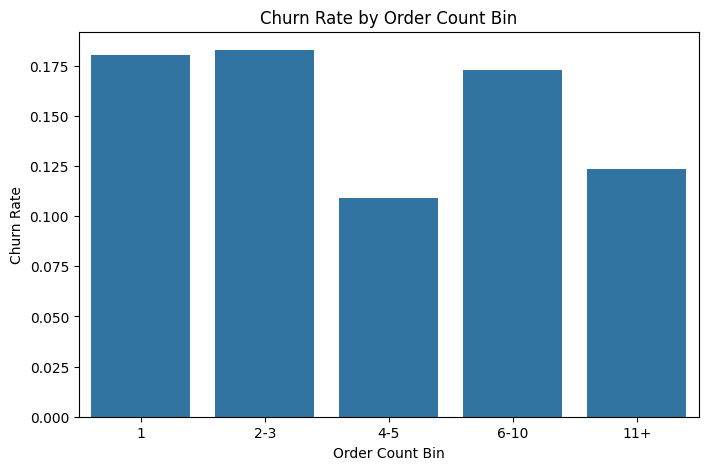

In [39]:
# OrderCount区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=order_count_bin_churn, x='OrderCount_bin', y='churn_rate')
plt.title('Churn Rate by Order Count Bin')
plt.xlabel('Order Count Bin')
plt.ylabel('Churn Rate')
plt.show()

- `OrderCount` を区間ごとに分けて離脱率を確認した。
- 注文回数が少ない顧客ほど離脱率が高い、という単純な傾向は見られなかった。
- 一方で、注文回数の区間ごとに離脱率には一定の差が見られる。
- 特に `1` や `2-3` の低頻度注文層では、離脱率が約18%前後となっている。
- ただし、注文回数が多い区間でも離脱率が高い箇所があり、`OrderCount` 単独で離脱傾向を説明するのは難しい。
- このことから、`OrderCount` は他の特徴量と組み合わせて利用することで有用になる可能性がある。
- 後続のモデル構築では、`OrderCount` を特徴量として使用し、モデル内での重要度を確認する。

### 2.5 最終注文からの日数と離脱率の関係

最終注文からの日数を表す `DaySinceLastOrder` と離脱率の関係を確認する。

一般的には、最終注文から日数が経過している顧客ほどサービス利用頻度が低下しており、離脱リスクが高い可能性がある。  
ここでは、最終注文からの日数を区間に分け、各区間ごとの離脱率を確認する。

In [41]:
# DaySinceLastOrderを区間に分ける
df['DaySinceLastOrder_bin'] = pd.cut(
    df['DaySinceLastOrder'],
    bins=[0, 3, 7, 14, np.inf],
    labels=['0-3', '4-7', '8-14', '15+'],
    include_lowest=True
)

# DaySinceLastOrder区間ごとの離脱率と件数を集計
last_order_churn = df.groupby('DaySinceLastOrder_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

last_order_churn

,DaySinceLastOrder_bin,churn_rate,count
0,0-3,0.215560,2802
1,4-7,0.136998,1219
2,8-14,0.095161,1240
3,15+,0.080645,62


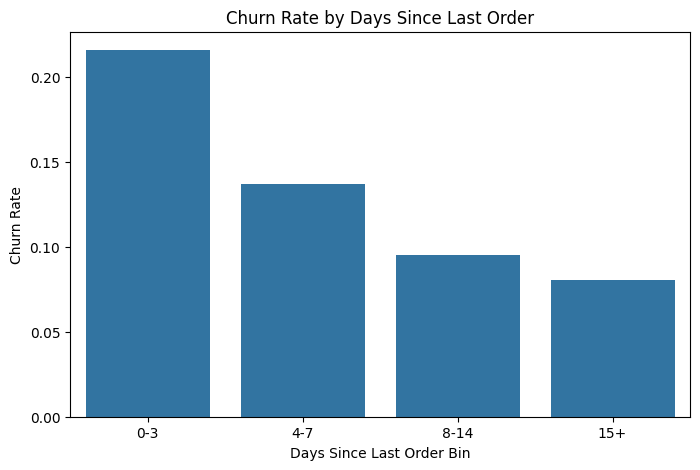

In [42]:
# DaySinceLastOrder区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=last_order_churn, x='DaySinceLastOrder_bin', y='churn_rate')
plt.title('Churn Rate by Days Since Last Order')
plt.xlabel('Days Since Last Order Bin')
plt.ylabel('Churn Rate')
plt.show()

- `DaySinceLastOrder` を区間ごとに分けて離脱率を確認した。
- 一般的には、最終注文から日数が経過している顧客ほど離脱リスクが高いと考えられる。
- しかし、本データでは `0-3` の区間で離脱率が最も高く、日数が長いほど離脱率が高くなるという単純な傾向は見られなかった。
- この結果から、`DaySinceLastOrder` は単独で離脱を説明するというより、`Tenure` や `Complain`、`OrderCount` など他の特徴量と組み合わせて解釈する必要がある。
- また、本データセットでは離脱判定の具体的なタイミングが明記されていないため、最終注文からの日数と離脱の関係は慎重に解釈する必要がある。
- 後続のモデル構築では、`DaySinceLastOrder` を特徴量として使用し、モデル内での重要度を確認する。